### Practical 2D pipeline test

* sample a smooth function at the nodal points
* nodal $\to$ modal
* apply SIAC
* evaluate DG and SIAC on fine grid
* compare DG and SIAC to exact

Goal: illustrate that SIAC improves smooth sampled data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.mesh import build_uniform_mesh_2d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_2d
from src.siac_modal import apply_siac_modal_dg_2d, trim_valid_siac_region_2d
from src.transforms import nodal_to_modal_2d
from src.evaluation import eval_dg_on_local_nodes_2d


In [3]:
# -----------------------------
# 0. Problem / domain setup
# -----------------------------
xmin, xmax = -3, 3
ymin, ymax = -3, 3
xlim = (xmin, xmax)
ylim = (ymin, ymax)

# --------------------------------------------------
# 1. Exact test function
# --------------------------------------------------
def exact_sine_scaled(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    # yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0
    u = np.sin(0.5*np.pi*x*y)
    return u

# DG polynomial degree  
p = 2
order = p + 1

# DG mesh resolution
domain_len_x, domain_len_y = int(np.floor(xmax-xmin)), int(np.floor(xmax-xmin))
Ky, Kx = 5*domain_len_y, 5*domain_len_x

# SIAC parameters
moments = 2 * p
BSorder = p + 1

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_2d(Kx, Ky, p=p, xlim=xlim, ylim=ylim)

# -----------------------------
# 3. Create sample grid
# -----------------------------
n_eval = order
nodes = local_cell_center_nodes_1d(n_eval)
X, Y = build_grid_from_local_nodes_2d(
    mesh,
    eval_nodes=nodes
)

# -----------------------------
# 3. Sample function and transform to nodal
# -----------------------------
arr = exact_sine_scaled(X, Y)
Unode = arr.reshape(Ky, order, Kx, order).transpose(0, 2, 1, 3)


# -----------------------------
# 5. transform to modal
# -----------------------------
dg = nodal_to_modal_2d(Unode, mesh=mesh, p=p)

# -----------------------------
# 6. Fine local nodes per element
# -----------------------------
n_eval_fine = 10 * n_eval
nodes_fine = local_cell_center_nodes_1d(n_eval_fine)
Xf, Yf = build_grid_from_local_nodes_2d(
    mesh=mesh, 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_sine_scaled(
    Xf, 
    Yf
)

U_dg = eval_dg_on_local_nodes_2d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_modal_dg_2d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_2d(
    U_exact,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_2d(
    U_dg,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_2d(
    U_siac,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)
# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))

DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 120
DG max err   : 0.0052872753329346045
DG rel err   : 0.0006871762288655962
SIAC max err : 0.000461401296282693
SIAC rel err : 0.00010079876809748379


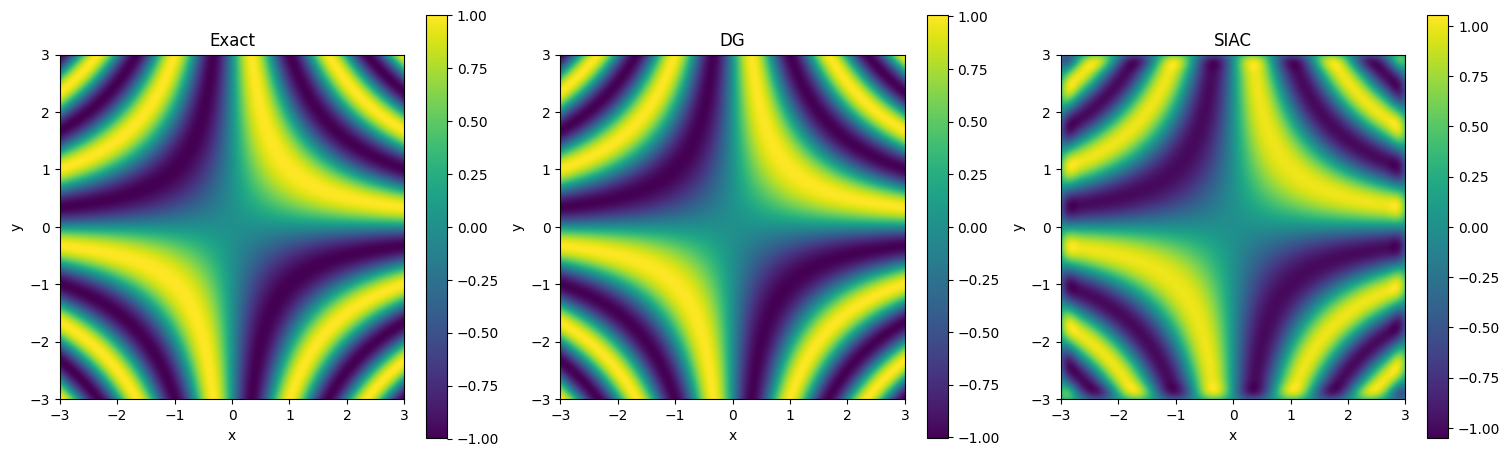

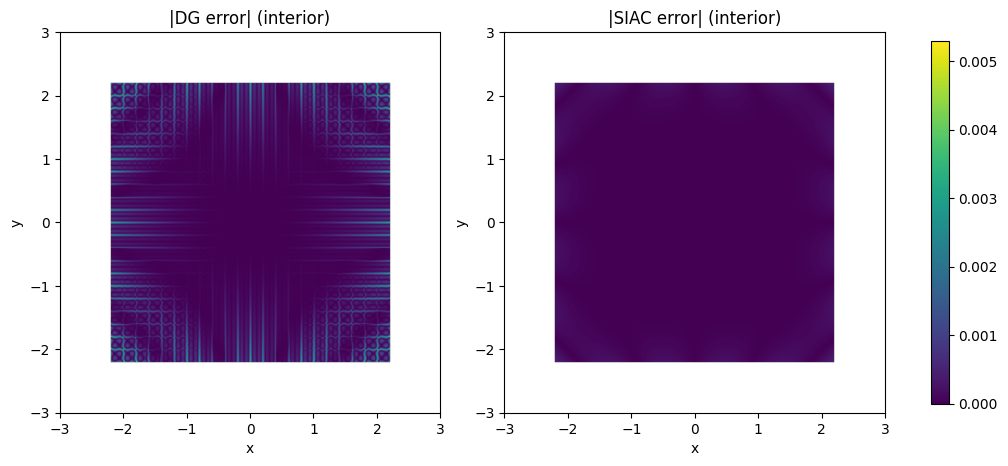

In [4]:

# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
# Visualize only the valid interior region while keeping full-size images:

dg_err_plot = np.full_like(U_exact, np.nan, dtype=float)
siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)

sl = slice(trim, -trim)
dg_err_plot[sl, sl] = np.abs(err_dg)
siac_err_plot[sl, sl] = np.abs(err_siac)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    U_exact,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    U_dg,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[1].set_title("DG")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    U_siac,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.show()

# --------------------------------------------------
# 8. Error plots
# --------------------------------------------------

rel_l2_err_siac = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)
rel_l2_err_dg = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)
ratio = rel_l2_err_siac / rel_l2_err_dg

use_shared_scale = (1e-2 <= ratio <= 1e2)

if use_shared_scale:
    vmin = 0.0
    vmax = max(np.max(np.abs(err_dg)),
               np.max(np.abs(err_siac)))
else:
    vmin = vmax = None

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im3 = axes[0].imshow(
    np.abs(dg_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("|DG error| (interior)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im4 = axes[1].imshow(
    np.abs(siac_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("|SIAC error| (interior)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar if same scale
if use_shared_scale:
    fig.colorbar(im3, ax=axes, location="right", shrink=0.9)
else:
    fig.colorbar(im3, ax=axes[0])
    fig.colorbar(im4, ax=axes[1])

plt.show()

### Test with noise

In [5]:

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_2d(Kx, Ky, p=p, xlim=xlim, ylim=ylim)

# -----------------------------
# 3. Create sample grid
# -----------------------------
n_eval = order
nodes = local_cell_center_nodes_1d(n_eval)
X, Y = build_grid_from_local_nodes_2d(
    mesh,
    eval_nodes=nodes
)

# -----------------------------
# 3. Sample function and transform to nodal
# -----------------------------
arr = exact_sine_scaled(X, Y)
Unode = arr.reshape(Ky, order, Kx, order).transpose(0, 2, 1, 3)

### Add Noise ###
rng = np.random.default_rng(seed=62)
hx, hy = mesh["hx"], mesh["hy"]
h = np.sqrt(hx**2 + hy**2)  #characteristic mesh length
sigma = h ** (p + 1)
noise = rng.standard_normal(size=Unode.shape) * sigma
Unode += noise

# -----------------------------
# 5. transform to modal
# -----------------------------
dg = nodal_to_modal_2d(Unode, mesh=mesh, p=p)

# -----------------------------
# 6. Fine local nodes per element
# -----------------------------
n_eval_fine = 10 * n_eval
nodes_fine = local_cell_center_nodes_1d(n_eval_fine)
Xf, Yf = build_grid_from_local_nodes_2d(
    mesh=mesh, 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_sine_scaled(
    Xf, 
    Yf
)

U_dg = eval_dg_on_local_nodes_2d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_modal_dg_2d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_2d(
    U_exact,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_2d(
    U_dg,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_2d(
    U_siac,
    n_eval=n_eval_fine,
    moments=moments,
    BSorder=BSorder
)
# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))

DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 120
DG max err   : 0.3535588764633475
DG rel err   : 0.04631023531811331
SIAC max err : 0.025765234986731
SIAC rel err : 0.009601371126830122


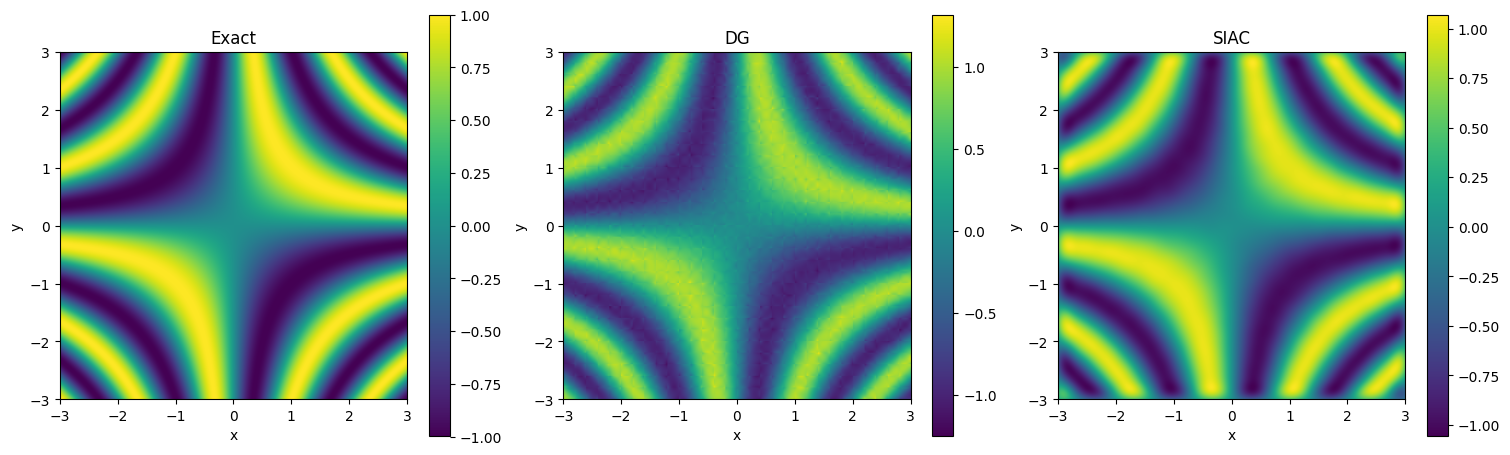

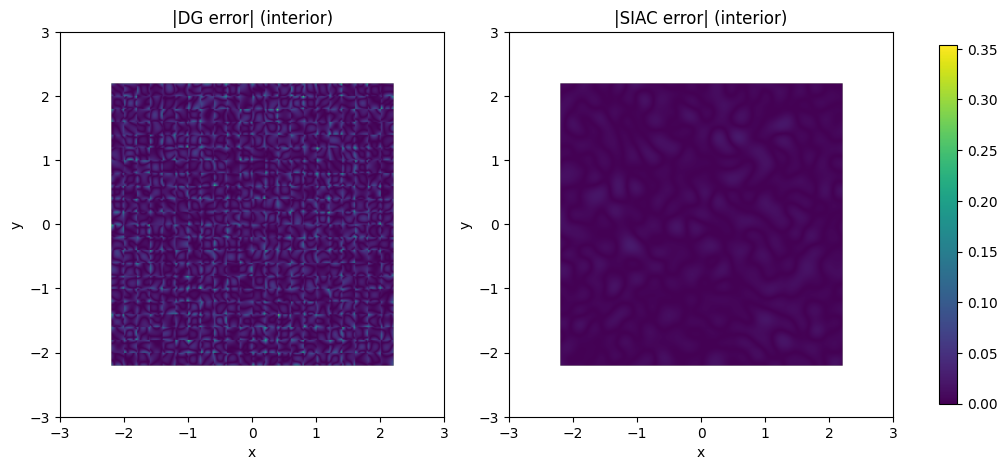

In [6]:

# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
# Visualize only the valid interior region while keeping full-size images:

dg_err_plot = np.full_like(U_exact, np.nan, dtype=float)
siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)

sl = slice(trim, -trim)
dg_err_plot[sl, sl] = np.abs(err_dg)
siac_err_plot[sl, sl] = np.abs(err_siac)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    U_exact,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    U_dg,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[1].set_title("DG")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    U_siac,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.show()

# --------------------------------------------------
# 8. Error plots
# --------------------------------------------------

rel_l2_err_siac = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)
rel_l2_err_dg = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)
ratio = rel_l2_err_siac / rel_l2_err_dg

use_shared_scale = (1e-2 <= ratio <= 1e2)

if use_shared_scale:
    vmin = 0.0
    vmax = max(np.max(np.abs(err_dg)),
               np.max(np.abs(err_siac)))
else:
    vmin = vmax = None

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im3 = axes[0].imshow(
    np.abs(dg_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("|DG error| (interior)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im4 = axes[1].imshow(
    np.abs(siac_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("|SIAC error| (interior)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar if same scale
if use_shared_scale:
    fig.colorbar(im3, ax=axes, location="right", shrink=0.9)
else:
    fig.colorbar(im3, ax=axes[0])
    fig.colorbar(im4, ax=axes[1])

plt.show()